# Oranges vs. Grapefruit

The task of separating oranges and grapefruit is fairly obvious to a human, but even with manual observation there is still a bit of error. This dataset takes the color, weight, and diameter of an "average" orange and grapefruit and generates a larger dataset containing a wide variety of values and are "oranges" and "grapefruit".

In [27]:
import pandas as pd
import numpy as np





In [28]:
data=pd.read_csv("../input/oranges-vs-grapefruit/citrus.csv")
data

,name,diameter,weight,red,green,blue
0,orange,2.96,86.76,172,85,2
1,orange,3.91,88.05,166,78,3
2,orange,4.42,95.17,156,81,2
3,orange,4.47,95.60,163,81,4
4,orange,4.48,95.76,161,72,9
...,...,...,...,...,...,...
9995,grapefruit,15.35,253.89,149,77,20
9996,grapefruit,15.41,254.67,148,68,7
9997,grapefruit,15.59,256.50,168,82,20
9998,grapefruit,15.92,260.14,142,72,11


In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      10000 non-null  object 
 1   diameter  10000 non-null  float64
 2   weight    10000 non-null  float64
 3   red       10000 non-null  int64  
 4   green     10000 non-null  int64  
 5   blue      10000 non-null  int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 468.9+ KB


In [30]:
data.describe()

,diameter,weight,red,green,blue
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,9.975685,175.050792,153.847800,76.010600,11.363200
std,1.947844,29.212119,10.432954,11.708433,9.061275
min,2.960000,86.760000,115.000000,31.000000,2.000000
25%,8.460000,152.220000,147.000000,68.000000,2.000000
50%,9.980000,174.985000,154.000000,76.000000,10.000000
75%,11.480000,197.722500,161.000000,84.000000,17.000000
max,16.450000,261.510000,192.000000,116.000000,56.000000


In [31]:
print(data["name"].unique())
print(" ")
print(data["name"].value_counts())

['orange' 'grapefruit']
 
grapefruit    5000
orange        5000
Name: name, dtype: int64


In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Preprocessing


In [33]:

def preprocessing(df):
    df=df.copy()
    
    #splitting
    y=df["name"].copy()
    X=df.drop("name",axis=1).copy()
     #Scalling
    scaler=StandardScaler()
    X=scaler.fit_transform(X)

    #training
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,train_size=0.7,random_state=123)
    
    return X_train,X_test,y_train,y_test



In [34]:
X_train,X_test,y_train,y_test=preprocessing(data)
X_train,X_test,y_train,y_test

(array([[-0.56253991, -0.55564622,  2.12339752,  0.34074582, -0.2608152 ],
        [ 2.1790903 ,  2.24264741, -0.84810523, -0.94044616,  1.06356803],
        [ 0.89555556,  0.91265344, -1.51908972, -1.11127176,  0.84283749],
        ...,
        [-0.30583296, -0.37865603,  0.58971868, -0.34255657,  0.29101114],
        [-1.15296589, -1.1622741 ,  0.68557361,  1.10946101, -0.48154574],
        [-0.40851574, -0.39406136,  0.78142854,  1.87817619, -1.03337209]]),
 array([[-7.16564075e-01, -7.25447251e-01, -1.03981508e+00,
         -9.05375665e-04, -1.03337209e+00],
        [-1.63044081e+00, -1.62751524e+00,  6.85573611e-01,
          9.38635408e-01, -8.12641549e-01],
        [ 1.59379846e+00,  1.60486652e+00,  8.77283465e-01,
         -7.69620563e-01,  5.11741680e-01],
        ...,
        [ 1.61373689e-01,  1.22873231e-01,  2.06298974e-01,
         -9.05375665e-04,  2.91011142e-01],
        [ 5.00226861e-01,  4.91231923e-01, -3.68830589e-01,
         -1.70916135e+00,  5.11741680e-01],
  

In [35]:
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

Model score value is : 94.06666666666666
              precision    recall  f1-score   support

  grapefruit       0.94      0.94      0.94      1509
      orange       0.94      0.94      0.94      1491

    accuracy                           0.94      3000
   macro avg       0.94      0.94      0.94      3000
weighted avg       0.94      0.94      0.94      3000



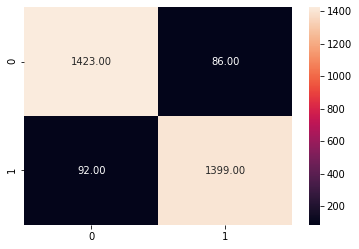

In [36]:
model_1=LogisticRegression()
model_1.fit(X_train,y_train)
print("Model score value is :",model_1.score(X_test,y_test)*100)

y_pred=model_1.predict(X_test)

# Evaluvation metric

from sklearn.metrics import classification_report,confusion_matrix
cm=confusion_matrix(y_pred,y_test)
sns.heatmap(cm,annot=True,fmt=".2f")

clr=classification_report(y_pred,y_test)
print(clr)

Model score value is : 94.53333333333333
              precision    recall  f1-score   support

  grapefruit       0.94      0.95      0.95      1491
      orange       0.95      0.94      0.95      1509

    accuracy                           0.95      3000
   macro avg       0.95      0.95      0.95      3000
weighted avg       0.95      0.95      0.95      3000



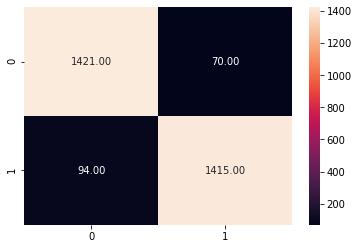

In [37]:
model=DecisionTreeClassifier()
model.fit(X_train,y_train)
print("Model score value is :",model.score(X_test,y_test)*100)

y_pred=model.predict(X_test)

# Evaluvation metric

from sklearn.metrics import classification_report,confusion_matrix
cm=confusion_matrix(y_pred,y_test)
sns.heatmap(cm,annot=True,fmt="0.2f")

clr=classification_report(y_pred,y_test)
print(clr)

Model score value is : 95.3
              precision    recall  f1-score   support

  grapefruit       0.95      0.95      0.95      1516
      orange       0.95      0.95      0.95      1484

    accuracy                           0.95      3000
   macro avg       0.95      0.95      0.95      3000
weighted avg       0.95      0.95      0.95      3000



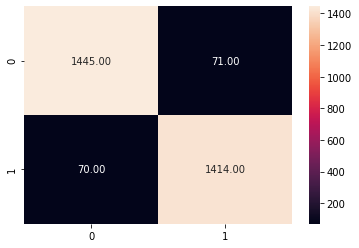

In [38]:
model_2=RandomForestClassifier()
model_2.fit(X_train,y_train)
print("Model score value is :",model_2.score(X_test,y_test)*100)

y_pred=model_2.predict(X_test)

# Evaluvation metric

from sklearn.metrics import classification_report,confusion_matrix
cm=confusion_matrix(y_pred,y_test)
sns.heatmap(cm,annot=True,fmt=".2f")

clr=classification_report(y_pred,y_test)
print(clr)

Model score value is : 95.26666666666667
              precision    recall  f1-score   support

  grapefruit       0.95      0.96      0.95      1507
      orange       0.95      0.95      0.95      1493

    accuracy                           0.95      3000
   macro avg       0.95      0.95      0.95      3000
weighted avg       0.95      0.95      0.95      3000



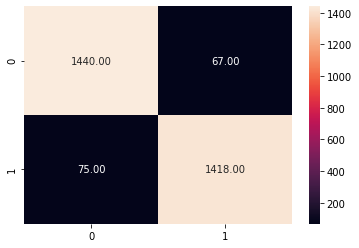

In [39]:
model_3=GradientBoostingClassifier()
model_3.fit(X_train,y_train)
print("Model score value is :",model_3.score(X_test,y_test)*100)

y_pred=model_3.predict(X_test)

# Evaluvation metric

from sklearn.metrics import classification_report,confusion_matrix
cm=confusion_matrix(y_pred,y_test)
sns.heatmap(cm,annot=True,fmt=".2f")

clr=classification_report(y_pred,y_test)
print(clr)